In [21]:
import nltk
from textblob import TextBlob
import re
import matplotlib.pyplot as plt
import json

# Handle potential SSL issues on macOS by checking for data first
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

print("System Ready: Essential NLP packages are loaded.")

[nltk_data] Downloading package punkt to /Users/welat/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /Users/welat/nltk_data...


System Ready: Essential NLP packages are loaded.


[nltk_data]   Unzipping corpora/stopwords.zip.


In [15]:
def clean_text(text):
    """Sanitizes raw input by removing emails, special chars, and normalizing case."""
    # Remove email addresses
    text = re.sub(r'\S*@\S*\s?', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Strip whitespace
    text = text.strip()
    return text

# Testing the cleaning process
sample_email = "Hello! I am very HAPPY with my order #5522. Contact me at support@test.com"
cleaned = clean_text(sample_email)
print(f"Original: {sample_email}")
print(f"Cleaned:  {cleaned}")

Original: Hello! I am very HAPPY with my order #5522. Contact me at support@test.com
Cleaned:  hello i am very happy with my order  contact me at


In [16]:
def analyze_priority(text):
    """Calculates sentiment and assigns priority based on emotional intensity."""
    analysis = TextBlob(text)
    # Polarity: -1 (Negative) to 1 (Positive)
    # Subjectivity: 0 (Objective) to 1 (Subjective/Emotional)
    sentiment = analysis.sentiment.polarity
    subjectivity = analysis.sentiment.subjectivity
    
    # Priority Logic
    if sentiment < -0.3 and subjectivity > 0.5:
        priority = "HIGH (Urgent Complaint)"
    elif sentiment < 0:
        priority = "MEDIUM (Feedback/Issue)"
    else:
        priority = "LOW (General Inquiry)"
        
    return priority, sentiment

# Testing Priority logic
test_text = "I am extremely disappointed because my shipment is 5 days late and no one is answering!"
cleaned_test = clean_text(test_text)
priority, score = analyze_priority(cleaned_test)

print(f"Text: {test_text}")
print(f"Score: {score} | Priority Status: {priority}")

Text: I am extremely disappointed because my shipment is 5 days late and no one is answering!
Score: -0.525 | Priority Status: HIGH (Urgent Complaint)


In [17]:
def classify_intent(text):
    """Classifies the purpose of the message using keyword mapping."""
    text = text.lower()
    
    # Intent dictionary (Keyword mapping)
    intents = {
        "Refund/Return": ["refund", "return", "money back", "reimbursement"],
        "Logistics/Shipping": ["shipping", "delivery", "track", "cargo", "arrived"],
        "Technical Support": ["login", "error", "bug", "broken", "not working"],
        "Greetings": ["hello", "hi", "greetings", "morning", "hey"]
    }
    
    for intent, keywords in intents.items():
        if any(keyword in text for keyword in keywords):
            return intent
            
    return "Other/General"

# Testing Intent classification
test_mail = "I want to track my delivery, it is late."
intent = classify_intent(test_mail)
print(f"Detected Intent: {intent}")

Detected Intent: Logistics/Shipping


In [18]:
def sentience_engine(raw_text):
    """Main pipeline that combines cleaning, priority, and intent analysis."""
    cleaned = clean_text(raw_text)
    priority, score = analyze_priority(cleaned)
    intent = classify_intent(cleaned)
    
    return {
        "original_text": raw_text,
        "sentiment_score": round(score, 2),
        "detected_intent": intent,
        "priority_level": priority
    }

# Running a realistic scenario
example_mail = "Hello, I am very angry! I want a refund because my item is broken."
result = sentience_engine(example_mail)
print(json.dumps(result, indent=4))

{
    "original_text": "Hello, I am very angry! I want a refund because my item is broken.",
    "sentiment_score": -0.53,
    "detected_intent": "Refund/Return",
    "priority_level": "HIGH (Urgent Complaint)"
}


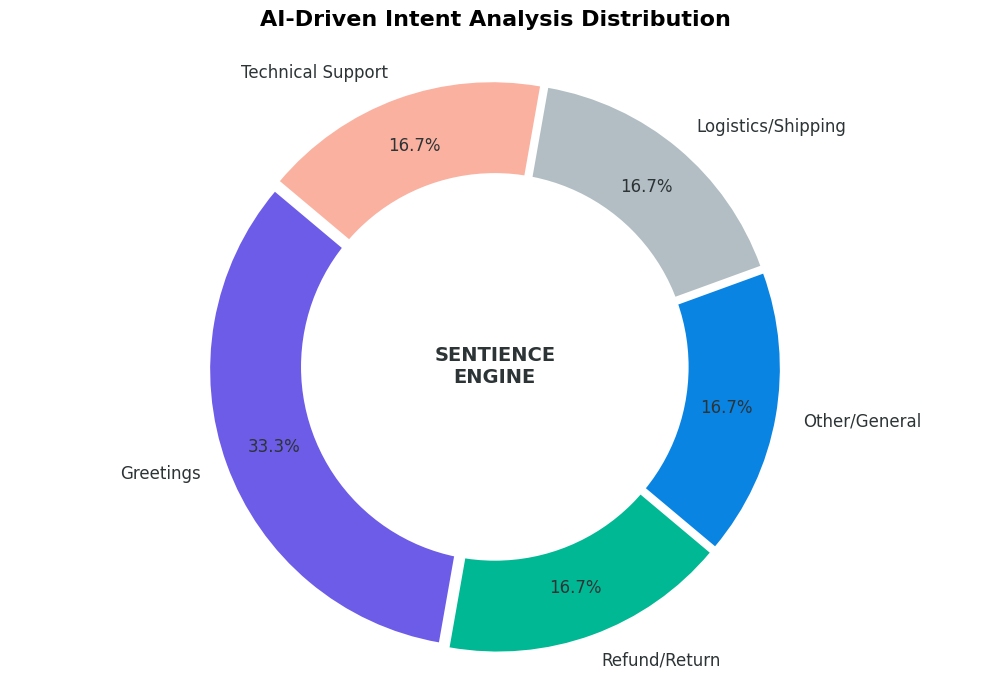

In [19]:
# Prepare a batch of sample data for visualization
sample_emails = [
    "I love this product!", "My order is broken, refund please.",
    "Where is my package?", "Login error on the website.",
    "Hi there, just saying hello.", "Terrible experience, very late delivery."
]

# Run engine on batch
results = [sentience_engine(email) for email in sample_emails]
intents_list = [r['detected_intent'] for r in results]

# Plotting
intent_counts = {i: intents_list.count(i) for i in set(intents_list)}
labels = list(intent_counts.keys())
values = list(intent_counts.values())
premium_colors = ['#6C5CE7', '#00B894', '#0984E3', '#B2BEC3', '#FAB1A0']

fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')
wedges, texts, autotexts = ax.pie(
    values, labels=labels, autopct='%1.1f%%', 
    startangle=140, colors=premium_colors, pctdistance=0.82,
    explode=[0.03] * len(labels),
    textprops={'fontsize': 12, 'fontweight': '500', 'color': '#2D3436'}
)

centre_circle = plt.Circle((0,0), 0.70, fc='white', linewidth=1.25)
fig.gca().add_artist(centre_circle)
ax.text(0, 0, 'SENTIENCE\nENGINE', ha='center', va='center', 
        fontsize=14, fontweight='bold', color='#2D3436')

plt.title('AI-Driven Intent Analysis Distribution', fontsize=16, pad=20, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()